# Notebook 3 — Exploratory Data Analysis
Disease distribution, symptom frequency, correlation analysis, and visualisations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

OUT = '../data/processed/'
train = pd.read_csv(f'{OUT}train_disease_clean.csv')
drug  = pd.read_csv(f'{OUT}drug_train_clean.csv')

symptom_cols = [c for c in train.columns if c not in ('prognosis', 'prognosis_enc')]

## 3.1 Disease Distribution

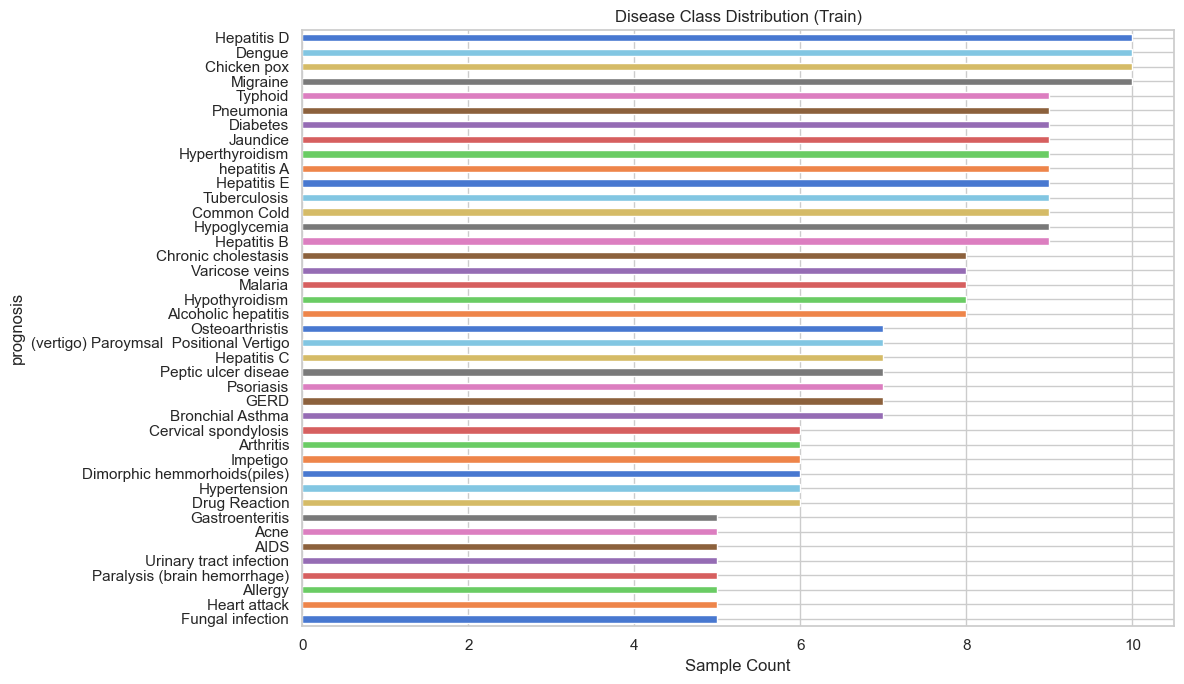

prognosis
Hepatitis D                                10
Dengue                                     10
Chicken pox                                10
Migraine                                   10
Hepatitis B                                 9
Hypoglycemia                                9
Common Cold                                 9
Tuberculosis                                9
Hepatitis E                                 9
hepatitis A                                 9
Typhoid                                     9
Hyperthyroidism                             9
Jaundice                                    9
Diabetes                                    9
Pneumonia                                   9
Varicose veins                              8
Malaria                                     8
Hypothyroidism                              8
Alcoholic hepatitis                         8
Chronic cholestasis                         8
Osteoarthristis                             7
Bronchial Asthma        

In [2]:
dist = train['prognosis'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
dist.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(dist)))
ax.set_xlabel('Sample Count')
ax.set_title('Disease Class Distribution (Train)')
plt.tight_layout()
plt.show()
print(dist)

## 3.2 Symptom Frequency

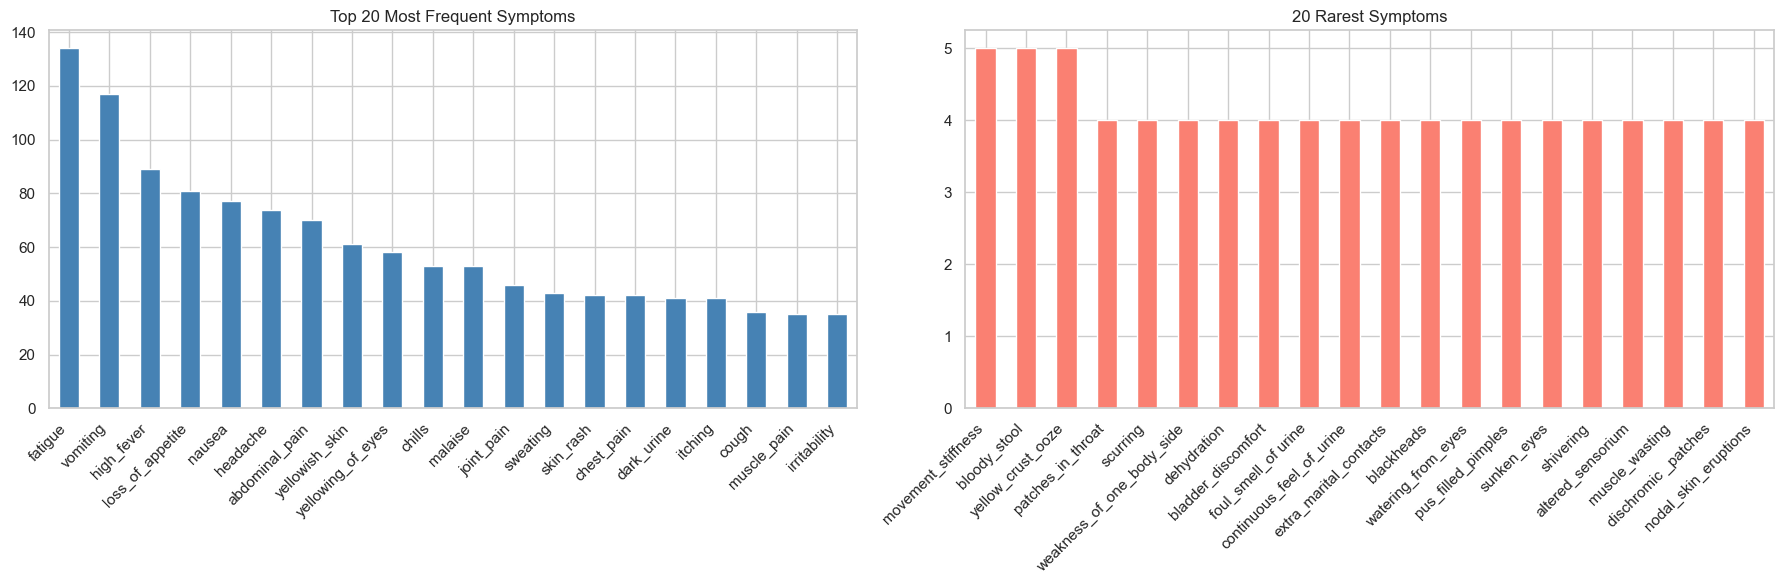

In [3]:
sym_freq = train[symptom_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20
sym_freq.head(20).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Most Frequent Symptoms')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Bottom 20 (rarest)
sym_freq.tail(20).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('20 Rarest Symptoms')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 3.3 Symptom Heatmap per Disease

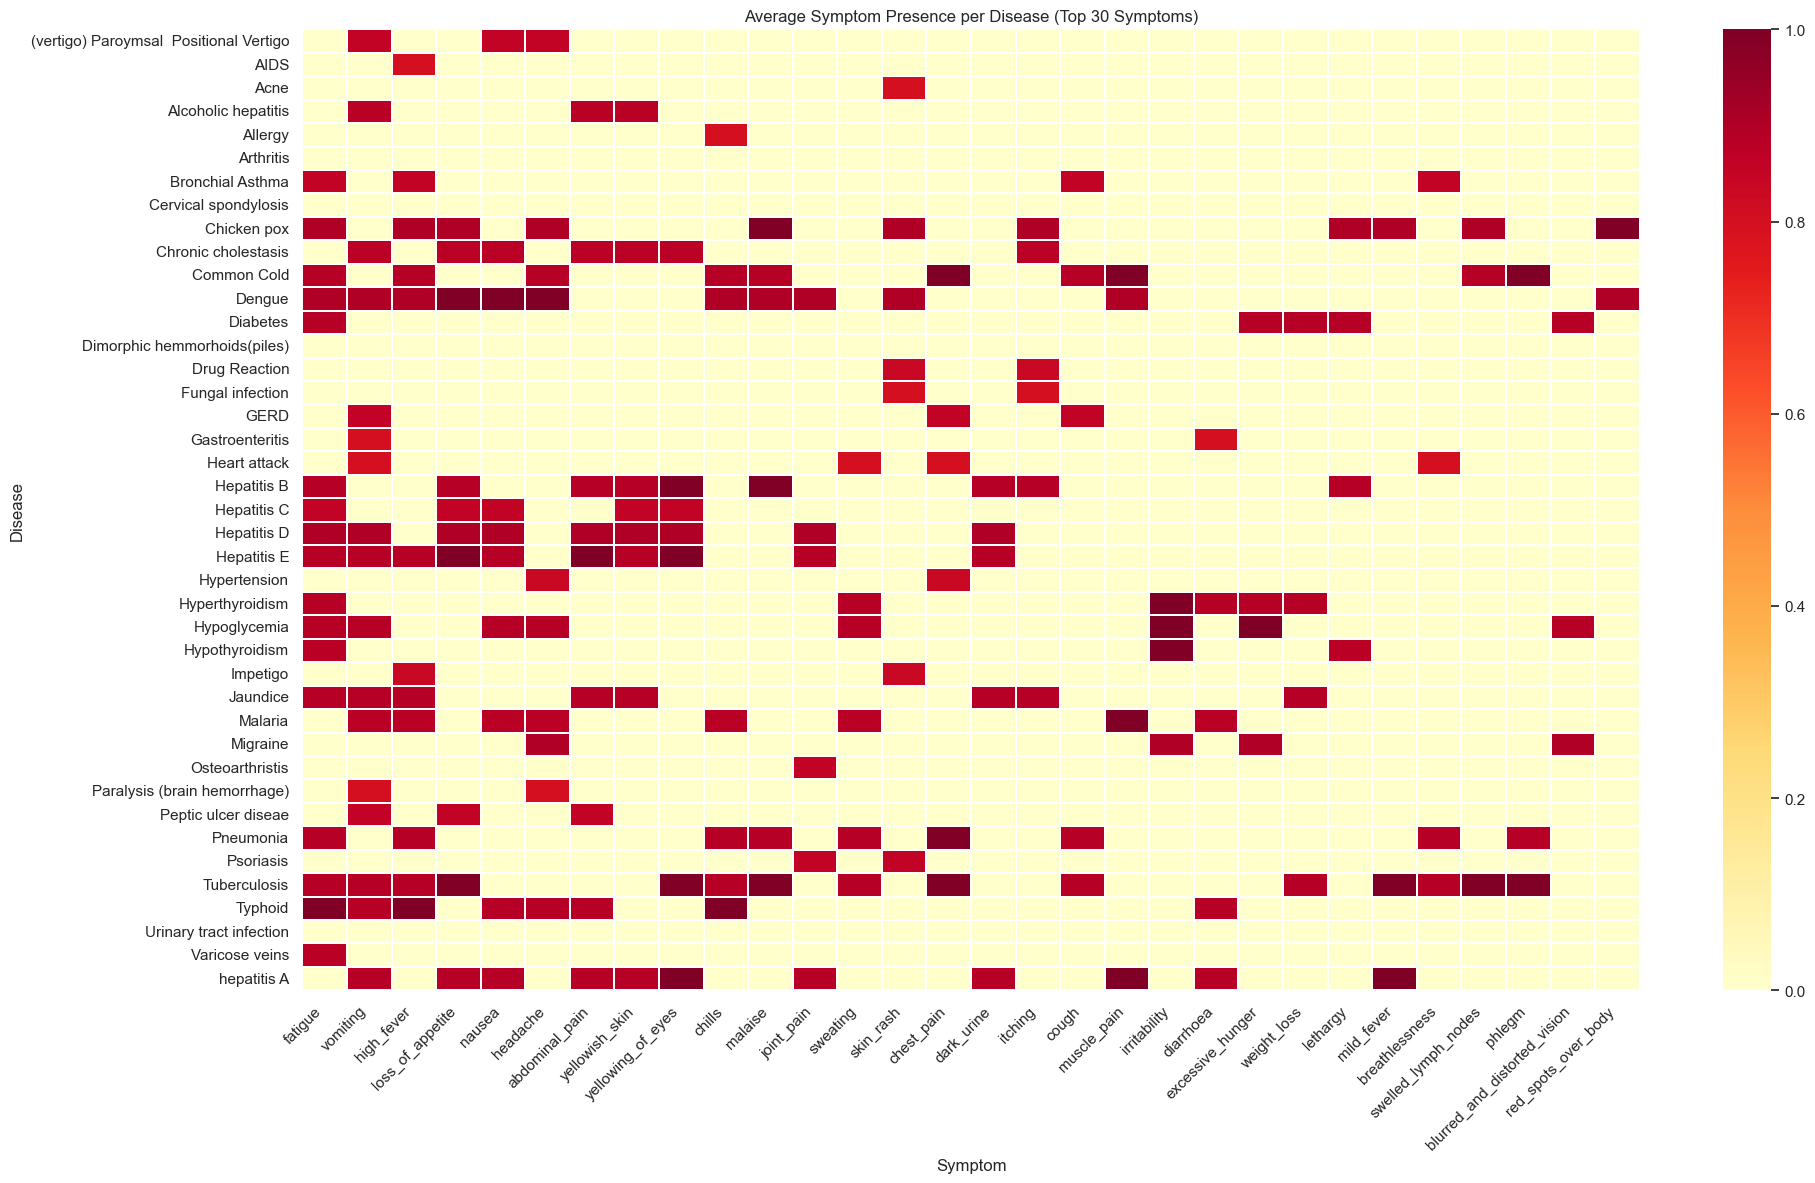

In [4]:
# Average symptom presence per disease — use top 30 symptoms by frequency
top30 = sym_freq.head(30).index.tolist()
disease_symptom = train.groupby('prognosis')[top30].mean()

fig, ax = plt.subplots(figsize=(20, 12))
sns.heatmap(disease_symptom, cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_title('Average Symptom Presence per Disease (Top 30 Symptoms)')
ax.set_xlabel('Symptom')
ax.set_ylabel('Disease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.4 Symptom Correlation Analysis

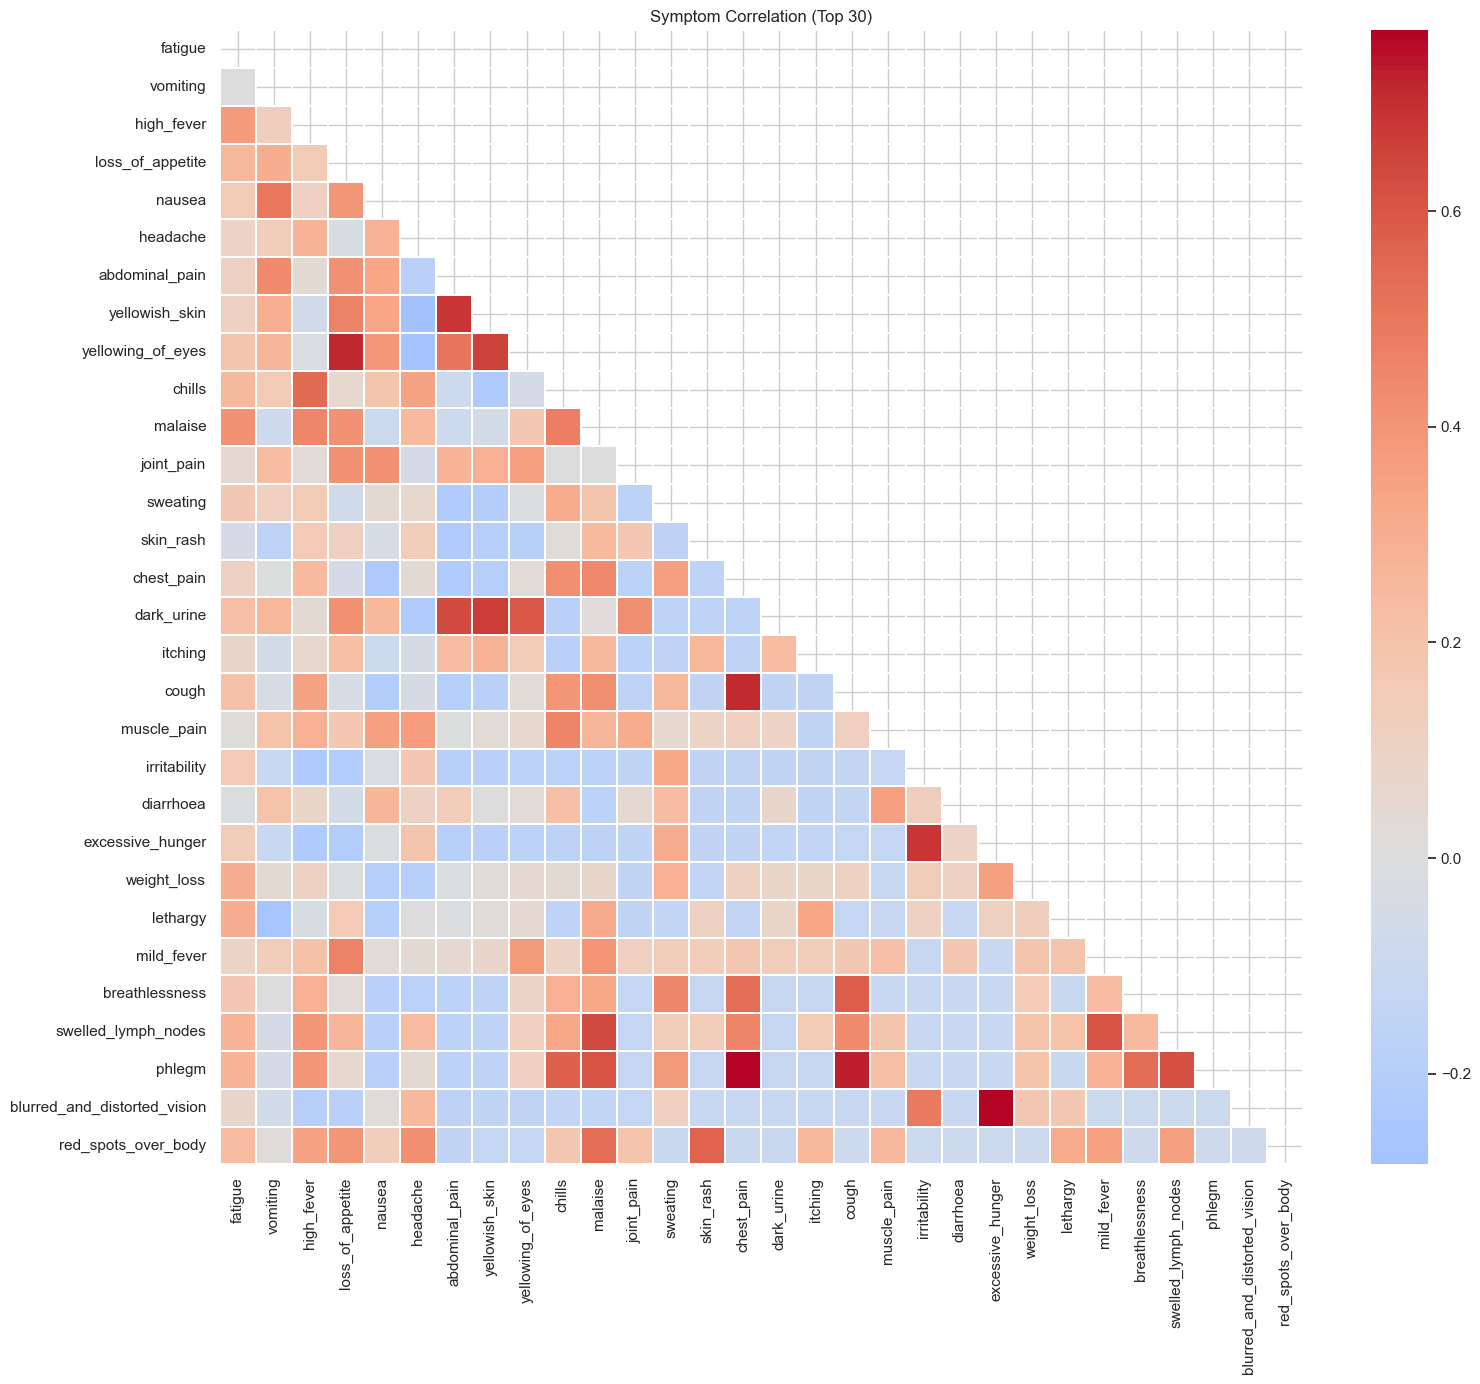

Top 10 correlated symptom pairs:
                          s1               s2     corr
blurred_and_distorted_vision excessive_hunger 0.767567
                      phlegm       chest_pain 0.763819
                      phlegm            cough 0.725201
           yellowing_of_eyes loss_of_appetite 0.710987
                       cough       chest_pain 0.708870
            excessive_hunger     irritability 0.689488
              yellowish_skin   abdominal_pain 0.681938
                  dark_urine   yellowish_skin 0.667819
           yellowing_of_eyes   yellowish_skin 0.655580
         swelled_lymph_nodes          malaise 0.634521


In [5]:
# Correlation among top 30 symptoms
corr = train[top30].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Symptom Correlation (Top 30)')
plt.tight_layout()
plt.show()

# Strongest pairs
corr_pairs = (corr.where(~mask)
               .stack()
               .reset_index()
               .rename(columns={'level_0':'s1','level_1':'s2', 0:'corr'})
               .sort_values('corr', key=abs, ascending=False))
print('Top 10 correlated symptom pairs:')
print(corr_pairs.head(10).to_string(index=False))

## 3.5 Drug Dataset EDA

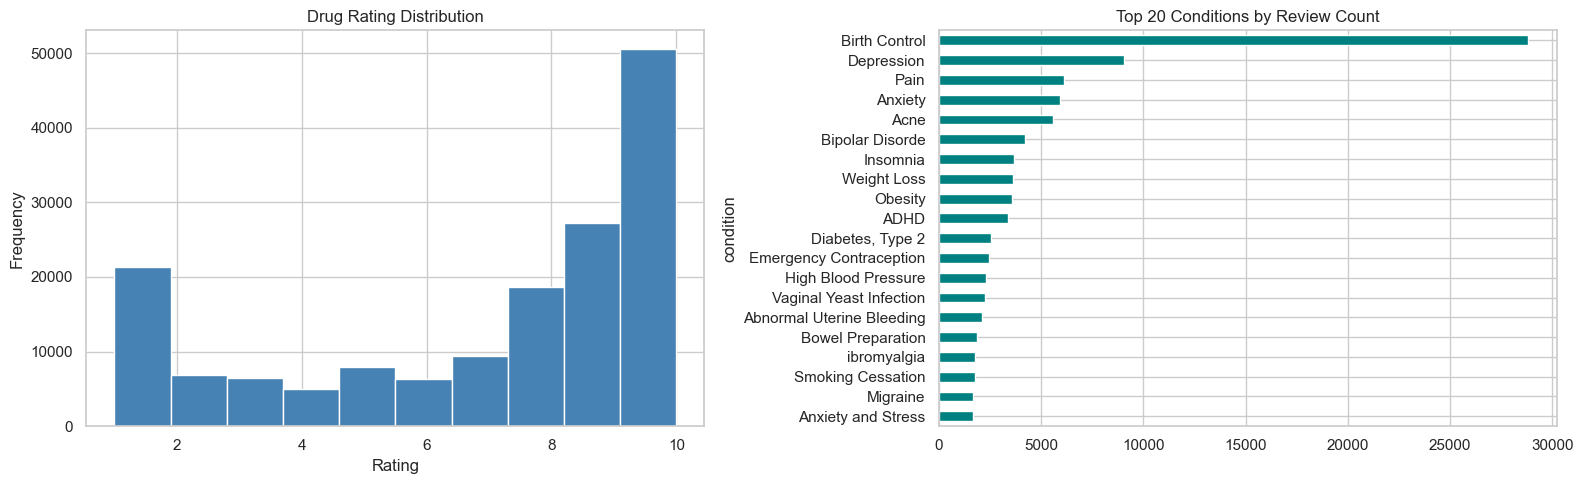

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Rating distribution
drug['rating'].plot(kind='hist', bins=10, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Drug Rating Distribution')
axes[0].set_xlabel('Rating')

# Top 20 conditions by review count
drug['condition'].value_counts().head(20).sort_values().plot(
    kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 20 Conditions by Review Count')
plt.tight_layout()
plt.show()

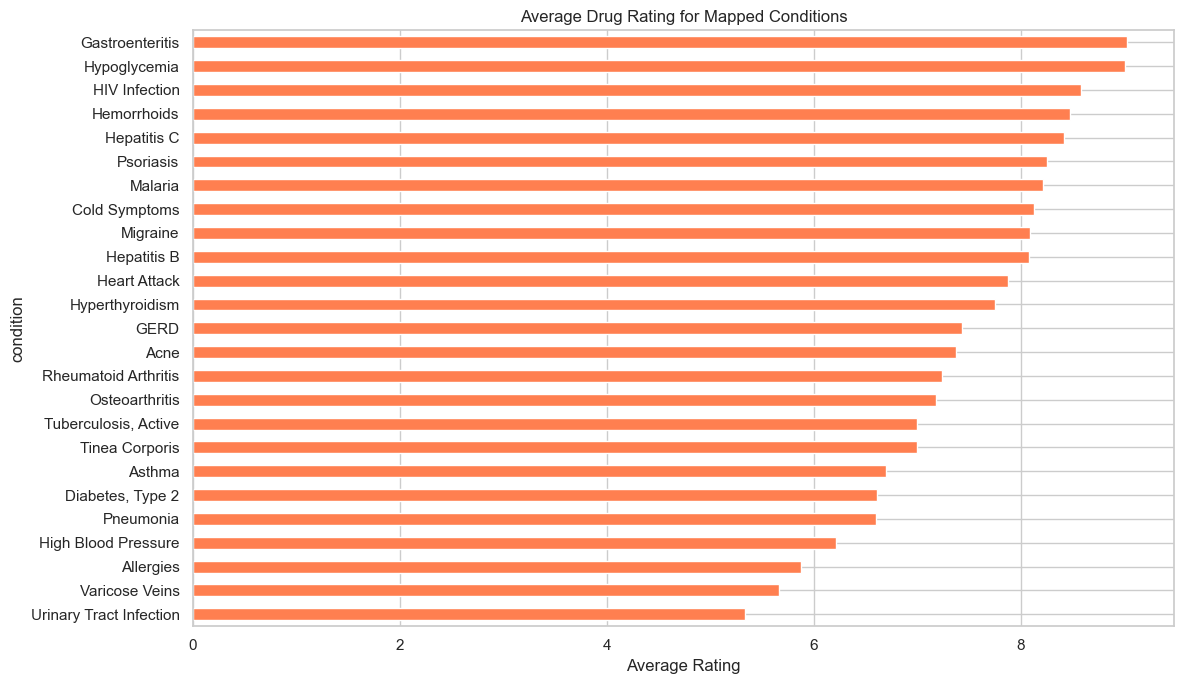

                             mean  count
condition                               
Gastroenteritis          9.026316     38
Hypoglycemia             9.000000      4
HIV Infection            8.578862    615
Hemorrhoids              8.477273     88
Hepatitis C              8.411585    656
Psoriasis                8.250836    598
Malaria                  8.210526     19
Cold Symptoms            8.120690    116
Migraine                 8.083235   1694
Hepatitis B              8.076923     13
Heart Attack             7.872727     55
Hyperthyroidism          7.750000     12
GERD                     7.427978    722
Acne                     7.374195   5588
Rheumatoid Arthritis     7.239196    995
Osteoarthritis           7.175948   1239
Tuberculosis, Active     7.000000      1
Tinea Corporis           7.000000     25
Asthma                   6.697778    225
Diabetes, Type 2         6.611981   2554
Pneumonia                6.597826    276
High Blood Pressure      6.214994   2321
Allergies       

In [7]:
# Average drug rating per condition (mapped diseases only)
mapping = pd.read_csv('../data/processed/disease_condition_map.csv')
target_conditions = mapping['drug_condition'].unique()

cond_rating = (drug[drug['condition'].isin(target_conditions)]
               .groupby('condition')['rating']
               .agg(['mean', 'count'])
               .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(12, 7))
cond_rating['mean'].sort_values().plot(kind='barh', ax=ax, color='coral')
ax.set_title('Average Drug Rating for Mapped Conditions')
ax.set_xlabel('Average Rating')
plt.tight_layout()
plt.show()
print(cond_rating)

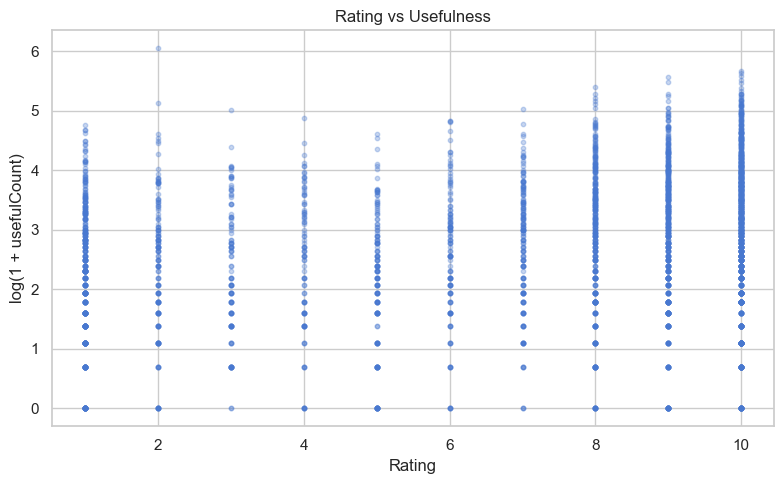

Correlation (rating, usefulCount): 0.235


In [8]:
# usefulCount vs rating scatter
sample = drug.sample(min(3000, len(drug)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample['rating'], np.log1p(sample['usefulCount']), alpha=0.3, s=10)
ax.set_xlabel('Rating')
ax.set_ylabel('log(1 + usefulCount)')
ax.set_title('Rating vs Usefulness')
plt.tight_layout()
plt.show()

print('Correlation (rating, usefulCount):', drug[['rating','usefulCount']].corr().iloc[0,1].round(3))